# Find out which tweet belongs to Elon Musk, Bill Gates, or Ed Lee

There are three excel files with approx 7000 tweets from Elon Musk, Bill Gates and Ed Lee (former San Francisco mayor).
The goal is to build a model that finds the author of any of those

In [45]:
import numpy as np
import pandas as pd
import string
import re
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import style

import warnings
warnings.filterwarnings('ignore')

## Data Loading

In [46]:
elondf=pd.read_excel("data/Elon Musk.xlsx")
bgatesdf=pd.read_excel("data/Bill Gates.xlsx") 
edleedf=pd.read_excel("data/Ed Lee.xlsx") 

print('Number of tweets @elonmusk: ' + str(elondf.shape[0]))
print('Number of tweets @BillGates: ' + str(bgatesdf.shape[0]))
print('Number of tweets @mayorEdlee: ' + str(edleedf.shape[0]))

# Merges all tweets into a single database
data = pd.concat([elondf, bgatesdf, edleedf], ignore_index=True)

# Selects only interesting columns
data = data[['screen_name', 'created_at', 'status_id', 'text']]
data.columns = ['author', 'date', 'id', 'text']

# Date parsing
data['date'] = pd.to_datetime(data['date'])
data.sample(15)

Number of tweets @elonmusk: 2678
Number of tweets @BillGates: 2087
Number of tweets @mayorEdlee: 2447


,author,date,id,text
2587,Elon Musk,2014-01-07 00:38:53+00:00,420353814579802112,Rough cut of Falcon 9 Thaicom flight http://t....
1676,Elon Musk,2017-05-22 02:00:11+00:00,866473736676950016,@jetkohli I'd highly recommend upgrading to la...
3805,Bill Gates,2017-06-06 21:57:31+00:00,872210872084582400,.@NIHDirector Thanks for a terrific visit. Mor...
98,Elon Musk,2015-10-21 23:19:38+00:00,656973144306094080,@bonnienorman thanks Bonnie :)
2859,Bill Gates,2017-09-13 17:17:07+00:00,908016707599347456,Progress can be hard to see. That’s why we’re ...
5182,Ed Lee,2016-12-20 19:22:22+00:00,811290664704962560,"In Chief Bill Scott, we've found a candidate t..."
1565,Elon Musk,2017-04-03 16:59:35+00:00,848943072423497728,"@waltmossberg @mims @defcon_5 Et tu, Walt?"
6308,Ed Lee,2017-04-16 21:31:53+00:00,853722640220946432,Declaring today Cherry Blossom Festival Day! O...
5322,Ed Lee,2015-11-10 04:08:15+00:00,663931145826897920,5M Project will provide 40% affordable housing...
3274,Bill Gates,2014-02-18 21:47:36+00:00,435893384847589376,"3 myths about education, the Common Core, and ..."


### Data Validation

Before modelling, we load the three tweet datasets separately to verify they loaded correctly and check their sizes. We then merge them into a single DataFrame and keep only the relevant columns (`author`, `date`, `id`, `text`). This gives us a unified dataset of ~7,200 tweets across three classes, which is our starting point for the classification task.

### Text Processing

Raw tweet text is noisy and unsuitable for direct modelling. We apply a multi-step NLP pipeline to normalize it:

1. **Clean text** — remove URLs, mentions, hashtags, punctuation, and numbers, which carry no authorship signal
2. **Tokenization** — split text into individual words using a regex tokenizer (`\w+`) to avoid splitting on punctuation
3. **Stop word removal** — filter out common English words (e.g. "the", "is") that appear across all authors and add no discriminative value
4. **Lemmatization** — reduce words to their base form (e.g. "running" → "run") to consolidate vocabulary
5. **Detokenization** — rejoin tokens into a single string, ready for vectorization

We first set up the required libraries and compare the NLTK and scikit-learn stop word lists to understand their coverage.

In [47]:
import nltk
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')

from nltk.stem.porter import *
from nltk.tokenize import RegexpTokenizer

from nltk.corpus import stopwords

nltkstop=stopwords.words('english')
print(len(nltkstop), "stop words provided by nltk: ")

198 stop words provided by nltk: 


[nltk_data] Downloading package punkt to /Users/theo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/theo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### Text Cleaning

Before tokenizing, we apply a `clean_text` function to strip tweet-specific noise: URLs, @mentions, #hashtags, punctuation, and digits. These elements don't help identify authorship and would inflate the vocabulary with low-signal tokens. We also lowercase everything at this stage to ensure consistent matching during stop word removal.

In [48]:
def clean_text(text):
    # Comments: Standardizing text to lower case and removing noise
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'@\w+', '', text) # Remove mentions (@user)
    text = re.sub(r'#\w+', '', text) # Remove hashtags
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = text.strip()
    return text

#### Train / Test Split

We split the data before any text preprocessing to avoid **data leakage** — the preprocessing pipeline (especially the vectorizer vocabulary) must be fit only on training data and then applied to the test set. We use a 70/30 split with stratification to ensure all three authors are proportionally represented in both sets.

In [49]:
from sklearn.model_selection import train_test_split

def split_df(dataframe, seed=None, percentage=0.8):
    X = dataframe[['text']]  # feature column
    y = dataframe['author']  # target column

    return train_test_split(X, 
                            y, 
                            test_size=1-percentage, 
                            random_state=seed, 
                            stratify=y)

X_train, X_test, Y_train, Y_test = split_df(data, seed=42, percentage=0.7)

print("Size of train dataset: ", X_train.shape)
print("Size of test dataset: ", X_test.shape)

X_train.head()


Size of train dataset:  (5048, 1)
Size of test dataset:  (2164, 1)


,text
5017,We're launching a ride share pilot program to ...
4585,Great questions coming in through #askbillg. W...
2859,Progress can be hard to see. That’s why we’re ...
6700,The grand opening of Duc Loi's Pantry provides...
4204,Here’s a great example of how teachers’ review...


#### Preprocessing Pipeline

We apply the full NLP pipeline to the training data. The pipeline uses the NLTK stop word list (198 words) — we compared it against scikit-learn's list (318 words) above to see the trade-off: a longer list removes more noise but risks dropping useful discriminative words. NLTK's more conservative list is chosen here.

The result is stored in `final_processed`, which contains the cleaned, lemmatized text ready for vectorization.

In [50]:
from sklearn.feature_extraction import text

skstop = text.ENGLISH_STOP_WORDS
print(len(skstop), "stop words provided by Sklearn: ")
print()
print(text.ENGLISH_STOP_WORDS)

318 stop words provided by Sklearn: 

frozenset({'describe', 'up', 'an', 'would', 'wherein', 're', 'done', 'could', 'latterly', 'her', 'such', 'go', 'move', 'upon', 'himself', 'itself', 'their', 'those', 'nine', 'take', 'whereas', 'everyone', 'herself', 'is', 'ever', 'serious', 'being', 'moreover', 'too', 'yet', 'well', 'might', 'whatever', 'third', 'due', 'amongst', 'keep', 'of', 'although', 'these', 'me', 'become', 'first', 'meanwhile', 'out', 'few', 'nobody', 'bottom', 'six', 'below', 'further', 'from', 'beforehand', 'twelve', 'while', 'where', 'us', 'front', 'them', 'co', 'you', 'we', 'system', 'last', 'when', 'always', 'to', 'anyway', 'not', 'off', 'there', 'whom', 'hereafter', 'have', 'his', 'before', 'sometimes', 'noone', 'elsewhere', 'something', 'call', 'everything', 'hence', 'at', 'for', 'are', 'any', 'fire', 'empty', 'since', 'fifteen', 'anyhow', 'will', 'again', 'hers', 'nevertheless', 'please', 'she', 'myself', 'yours', 'through', 'whence', 'per', 'anywhere', 'namely', 'wi

In [51]:
from nltk.corpus import stopwords

nltkstop=stopwords.words('english')
print(len(nltkstop), "stop words provided by nltk: ")
print()
print(nltkstop)

198 stop words provided by nltk: 

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 

In [52]:
import nltk
import spacy
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords

nltk.download('stopwords')
nltk.download('punkt')

nltkstop = set(stopwords.words('english'))
tokenizer = RegexpTokenizer(r'\w+')
nlp = spacy.load("en_core_web_sm", disable=['ner', 'parser'])

def text_preprocessing_steps(df, column_name):
    """
    Full pipeline showing each step: 
    Tokenization -> Stopwords -> Lemmatization -> Detokenization.
    """
    
    # Tokenization (Original text to list of words)
    # We also lowercase here to prepare for stopword removal
    print("Running Tokenization ...")
    df['step_1_tokens'] = df[column_name].apply(
        lambda x: [w.lower() for w in tokenizer.tokenize(str(x))]
    )

    # Elimination of Stop Words
    print("Removal of stop words ...")
    df['step_2_no_stop'] = df['step_1_tokens'].apply(
        lambda x: [item for item in x if item not in nltkstop]
    )

    # STEP 3: Lemmatization 
    print("Running Lemmatization...")
    raw_texts = [" ".join(t) for t in df['step_2_no_stop']]
    docs = nlp.pipe(raw_texts, batch_size=500)
    df['step_3_lemmas'] = [[token.lemma_ for token in doc] for doc in docs]

    print("Running Detokenization...")
    # Detokenization
    df['final_processed'] = df['step_3_lemmas'].apply(lambda x: " ".join(x))
    print("Text processing completed")
    return df

X_train = text_preprocessing_steps(X_train, 'text')

[nltk_data] Downloading package stopwords to /Users/theo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/theo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Running Tokenization ...
Removal of stop words ...
Running Lemmatization...
Running Detokenization...
Text processing completed


### 1. Bag of Words (BoW) Approach

The Bag of Words model represents each tweet as a vector of word counts, ignoring word order. Each unique word (or n-gram) in the training vocabulary becomes a feature, and the value is how often it appears in that tweet.

We use `CountVectorizer` with `ngram_range=(1, 2)` to capture both single words and two-word phrases — bigrams like "electric car" carry more meaning than either word alone and may help distinguish authors. The result is a sparse matrix where each row is a tweet and each column is a vocabulary token.

In [53]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    strip_accents = 'ascii', 
    lowercase = True, 
    ngram_range=(1, 2)
    )

X_train_transformed = vectorizer.fit_transform(X_train['final_processed'])

#### Model: Complement Naive Bayes

We use **Complement Naive Bayes (CNB)** rather than standard Multinomial NB. CNB is better suited for imbalanced text classification because it estimates the probability of a class by looking at the complement (all other classes) rather than the class itself, which corrects for the bias introduced when one class has more training examples. Our three authors have slightly different tweet counts, making CNB a more robust choice.

In [54]:
X_train_transformed.shape

(5048, 54837)

In [55]:
from sklearn.naive_bayes import ComplementNB

complement_nb = ComplementNB()
complement_nb.fit(X_train_transformed, Y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueOnly used in edge case with a single class in the training set.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. Not used.",None
,"norm norm: bool, default=FalseWhether or not a second normalization of the weights is performed. Thedefault behavior mirrors the implementations found in Mahout and Weka,which do not follow the full algorithm described in Table 9 of thepaper.",False


In [56]:
X_test_transformed = text_preprocessing_steps(X_test, 'text')
X_test_transformed = vectorizer.transform(X_test_transformed['final_processed'])

y_train_pred = complement_nb.predict(X_train_transformed)
y_test_pred = complement_nb.predict(X_test_transformed)

Running Tokenization ...
Removal of stop words ...
Running Lemmatization...
Running Detokenization...
Text processing completed


#### Evaluation

We evaluate on both train and test sets to check for overfitting. A large gap between training and test accuracy indicates the model has memorised training data rather than generalising. We report:
- **Accuracy** — overall proportion of correct predictions
- **Precision / Recall / F1** — per-author metrics to see if the model struggles more with specific authors
- **Confusion matrix** — to identify which authors are being confused with each other

In [57]:
from sklearn.metrics import accuracy_score, classification_report

train_acc = accuracy_score(Y_train, y_train_pred)
test_acc = accuracy_score(Y_test, y_test_pred)

print(f"--- Performance Comparison ---")
print(f"Training Accuracy: {train_acc:.2%}")
print(f"Test Accuracy:     {test_acc:.2%}")
print(f"Difference:         {train_acc - test_acc:.2%}")
print("-" * 30)

--- Performance Comparison ---
Training Accuracy: 99.82%
Test Accuracy:     92.28%
Difference:         7.54%
------------------------------


In [58]:
print("\n[TRAIN CLASSIFICATION REPORT]")
print(classification_report(Y_train, y_train_pred, target_names=['Elon Musk', 'Bill Gates', 'Ed Lee']))

print("\n[TEST CLASSIFICATION REPORT]")
print(classification_report(Y_test, y_test_pred, target_names=['Elon Musk', 'Bill Gates', 'Ed Lee']))



[TRAIN CLASSIFICATION REPORT]
              precision    recall  f1-score   support

   Elon Musk       1.00      1.00      1.00      1461
  Bill Gates       1.00      1.00      1.00      1713
      Ed Lee       1.00      1.00      1.00      1874

    accuracy                           1.00      5048
   macro avg       1.00      1.00      1.00      5048
weighted avg       1.00      1.00      1.00      5048


[TEST CLASSIFICATION REPORT]
              precision    recall  f1-score   support

   Elon Musk       0.86      0.96      0.91       626
  Bill Gates       0.91      0.98      0.95       734
      Ed Lee       0.99      0.84      0.91       804

    accuracy                           0.92      2164
   macro avg       0.92      0.93      0.92      2164
weighted avg       0.93      0.92      0.92      2164



### 2. TF-IDF Approach

**TF-IDF (Term Frequency–Inverse Document Frequency)** improves on BoW by down-weighting words that appear frequently across all tweets (and are therefore not useful for distinguishing authors) while up-weighting rare, distinctive words.

- **TF (Term Frequency)**: how often a word appears in a specific tweet
- **IDF (Inverse Document Frequency)**: penalises words common across all tweets

A word like "today" appears in all three authors' tweets and gets a low IDF weight. A word like "Tesla" is rare globally and distinctive to Elon Musk, getting a high TF-IDF score.

The two key parameters we tune are `max_df` and `min_df` to filter out uninformative extremes of the vocabulary.

we can play with these two parameters:
- max_df: Ignores words that appear in more than this % of documents
- min_df: Ignores words that appear in fewer than this # documents. Sometimes they are just noise, typos or rare terms that are not useful to identify the authors. The danger is to remove very specific terms that identified them

#### BoW vs TF-IDF: A Simple Example

To understand the difference, consider these 3 sentences:

1. The sun is shining
2. The weather is sweet
3. The sun is shining, the weather is sweet, and one and one is two

With **BoW**, the word "is" gets a high count in sentence 3 — making it look very important. But "is" appears in all sentences and carries no meaning. **TF-IDF** corrects this by penalising words that are common across all documents, so distinctive words are weighted higher.

In [59]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
np.set_printoptions(precision=2)

count = CountVectorizer()
docs = np.array([
        'The sun is shining',
        'The weather is sweet',
        'The sun is shining, the weather is sweet, and one and one is two'])
bag = count.fit_transform(docs)

In [60]:
print(count.vocabulary_)

{'the': 6, 'sun': 4, 'is': 1, 'shining': 3, 'weather': 8, 'sweet': 5, 'and': 0, 'one': 2, 'two': 7}


In [61]:
df_example = pd.DataFrame(
    bag.toarray(),
    columns=count.get_feature_names_out()
)
df_example

,and,is,one,shining,sun,sweet,the,two,weather
0,0,1,0,1,1,0,1,0,0
1,0,1,0,0,0,1,1,0,1
2,2,3,2,1,1,1,2,1,1


Notice "is" has a high count in document 3 — but it's common to all documents and not meaningful. TF-IDF down-weights it using:

$$TF(w) = 1 + \ln(\text{count}(w)) \quad \text{if count}(w) > 0$$

$$IDF(w) = \ln\left(\frac{1 + N}{1 + \text{df}(w)}\right) + 1$$

$$\text{TF-IDF}(w, d) = TF(w, d) \times IDF(w, d)$$

Where $N$ is the number of documents and $\text{df}(w)$ is how many documents contain the word.

In [62]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer(use_idf=True, norm='l2', smooth_idf=True)
print(tfidf.fit_transform(count.fit_transform(docs)).toarray())

[[0.   0.43 0.   0.56 0.56 0.   0.43 0.   0.  ]
 [0.   0.43 0.   0.   0.   0.56 0.43 0.   0.56]
 [0.5  0.45 0.5  0.19 0.19 0.19 0.3  0.25 0.19]]


Notice that "is" — which had the highest count in document 3 — now has a relatively small TF-IDF weight because it appears in all three documents. Words unique to one document get higher weights, which is exactly what we want for authorship attribution.

#### Our TF-IDF Model

Now we apply TF-IDF to the actual tweet data using `TfidfVectorizer`, which combines the counting and IDF transformation in one step. We use `max_df=0.95` to ignore words appearing in over 95% of tweets (too common to be discriminative) and `min_df=10` to ignore words appearing in fewer than 10 tweets (likely noise or typos).

In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_df=0.95,
    min_df=10
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train['final_processed'])
print(type(X_train_tfidf))
print(X_train_tfidf.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(5048, 1047)


We fit and train a new Complement Naive Bayes model on the TF-IDF matrix. We use `LabelEncoder` to convert the author names to numeric class labels (required by the model), and apply the same preprocessing and vectorization to the test set — using `transform` only (never `fit_transform`) to avoid leakage.

In [64]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
Y_train_numeric = le.fit_transform(Y_train)
Y_test_numeric = le.transform(Y_test)

cnb_model = ComplementNB()
cnb_model.fit(X_train_tfidf, Y_train_numeric)

X_test_tfidf = tfidf_vectorizer.transform(X_test['final_processed'])

cutoff = 0.5
train_predict = cnb_model.predict(X_train_tfidf)
test_predict = cnb_model.predict(X_test_tfidf)

#### Results

We compare TF-IDF performance against BoW. TF-IDF often generalises slightly better because it reduces the influence of frequent but uninformative words, though for short texts like tweets the improvement may be modest.

In [65]:
print(f"--- [TRAIN] CLASSIFICATION REPORT ---")
print(classification_report(Y_train_numeric, train_predict, target_names=le.classes_))

print("-" * 55)

print(f"--- [TEST] CLASSIFICATION REPORT ---")
print(classification_report(Y_test_numeric, test_predict, target_names=le.classes_))

--- [TRAIN] CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

  Bill Gates       0.86      0.95      0.91      1461
      Ed Lee       0.94      0.97      0.95      1713
   Elon Musk       0.97      0.86      0.91      1874

    accuracy                           0.92      5048
   macro avg       0.92      0.93      0.92      5048
weighted avg       0.93      0.92      0.92      5048

-------------------------------------------------------
--- [TEST] CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

  Bill Gates       0.81      0.93      0.86       626
      Ed Lee       0.91      0.96      0.93       734
   Elon Musk       0.94      0.79      0.86       804

    accuracy                           0.89      2164
   macro avg       0.89      0.89      0.89      2164
weighted avg       0.89      0.89      0.89      2164



Confusion Matrix


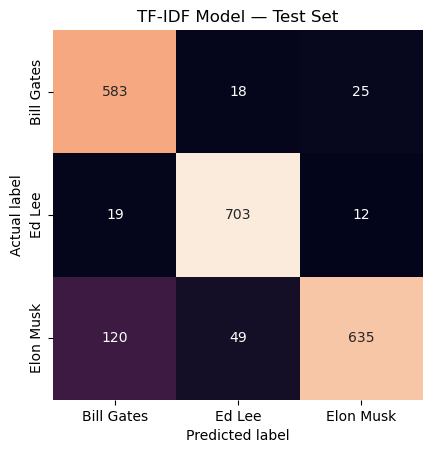

In [66]:
from sklearn.metrics import confusion_matrix

print("Confusion Matrix")
mat = confusion_matrix(Y_test_numeric, test_predict)

labels = le.classes_
sns.heatmap(mat, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title('TF-IDF Model — Test Set')
plt.show()

### 3. TF-IDF Parameter Tuning

We use `GridSearchCV` with a `Pipeline` (TfidfVectorizer → ComplementNB) to find the best combination of:
- `max_df` — upper document frequency threshold (removes words too common across all tweets)
- `min_df` — minimum document count (removes rare noise)
- `ngram_range` — unigrams only vs. unigrams + bigrams
- `sublinear_tf` — whether to apply log normalization to term frequency (often helps with NB)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', ComplementNB())
])

param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'tfidf__max_df':      [0.7, 0.8, 0.9, 0.95],
    'tfidf__min_df':      [1, 5, 10, 20],
    'tfidf__sublinear_tf': [True, False],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train['final_processed'], Y_train)

print("Best parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV accuracy: {grid_search.best_score_:.4f}")

# Evaluate best model on test set
best_model = grid_search.best_estimator_
test_acc_tuned = best_model.score(X_test['final_processed'], Y_test)
print(f"Test accuracy with best params: {test_acc_tuned:.4f}")
print(f"\nImprovement over baseline TF-IDF (0.89): {test_acc_tuned - 0.89:+.4f}")

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_tuned = best_model.predict(X_test['final_processed'])

print("=== Best TF-IDF Model — Full Report ===")
print(classification_report(Y_test, y_pred_tuned, target_names=['Bill Gates', 'Ed Lee', 'Elon Musk']))

mat_tuned = confusion_matrix(Y_test, y_pred_tuned, labels=['Bill Gates', 'Ed Lee', 'Elon Musk'])
sns.heatmap(mat_tuned, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=['Bill Gates', 'Ed Lee', 'Elon Musk'],
            yticklabels=['Bill Gates', 'Ed Lee', 'Elon Musk'])
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title('Tuned TF-IDF Model — Test Set')
plt.show()